<a href="https://colab.research.google.com/github/JoelRomero123/datamining/blob/main/ARCHIVOS/Prestige.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from itertools import combinations
# 1. Cargar el archivo CSV

url="https://raw.githubusercontent.com/JoelRomero123/datamining/refs/heads/main/ARCHIVOS/Prestige_modificado.csv"
df=pd.read_csv(url, sep=';')
df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [2]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(102, 1)
  occupation;education;income;women;prestige;census;type_num
0   gov.administrators;13.11;12351;11.16;68.8;1113;1        
1      general.managers;12.26;25879;4.02;69.1;1130;1        
2            accountants;12.77;9271;15.7;63.4;1171;1        
3    purchasing.officers;11.42;8865;9.11;56.8;1175;1        
4              chemists;14.62;8403;11.68;73.5;2111;1        
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   occupation;education;income;women;prestige;census;type_num  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes
None
occupation;education;income;women;prestige;census;type_num    0
dtype: int64
0
       occupation;education;income;women;prestige;census;type_num
count                                                 102     

In [3]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

In [4]:
matriz_correlacion = variables_numericas.corr()

In [7]:
print(matriz_correlacion.round(3))
print(matriz_correlacion['Prestige'].sort_values(ascending=False).round(3))


Empty DataFrame
Columns: []
Index: []


KeyError: 'Prestige'

In [9]:
print(df.columns)

Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')


In [10]:
import matplotlib.pyplot as plt

plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

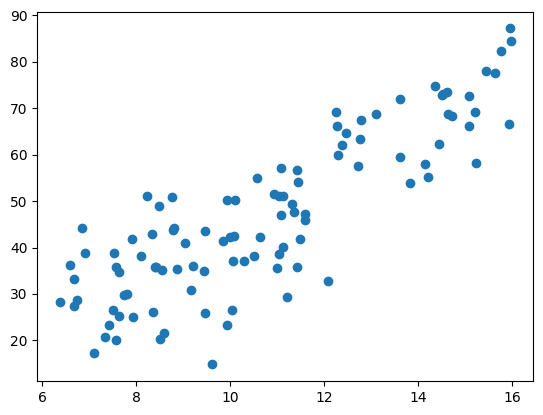

In [12]:
plt.scatter(df['education'], df['prestige'])

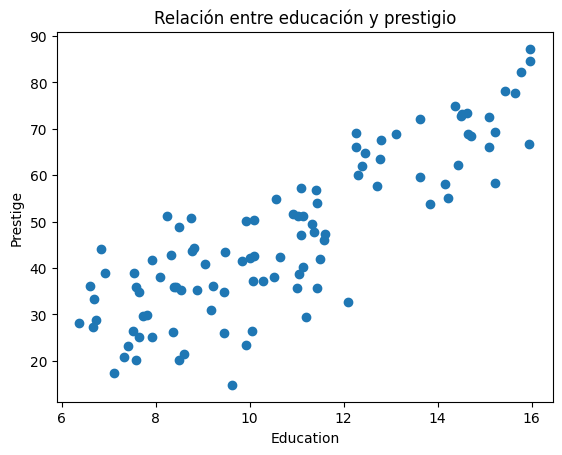

In [14]:
plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre educación y prestigio')
plt.show()

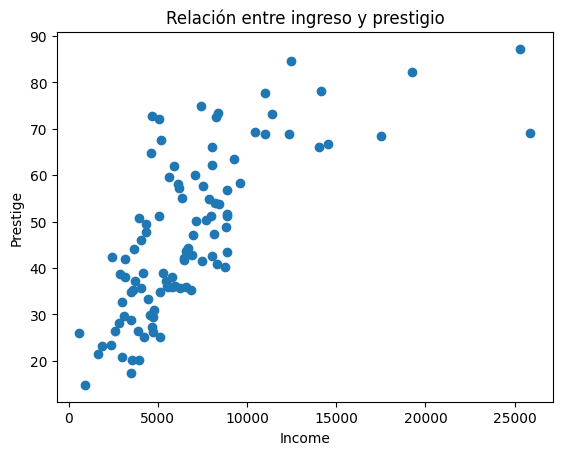

In [16]:
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [21]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [22]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)


In [23]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)


In [24]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)


In [25]:
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
